In [1]:
"""
# 02 — Primera CNN sobre MNIST

Módulo: 05 — Deep Learning para Clasificación  
Framework: TensorFlow / Keras  
Dataset: MNIST — dígitos escritos a mano (28×28 px, 10 clases)

## ¿Qué vamos a aprender en este notebook?

1. Cargar y explorar el dataset MNIST
2. Adaptar la CNN del notebook 01 para clasificación multiclase
3. Entender la diferencia entre clasificación binaria y multiclase
4. Analizar los resultados con una matriz de confusión
5. Identificar qué dígitos confunde el modelo y por qué
"""

'\n# 02 — Primera CNN sobre MNIST\n\nMódulo: 05 — Deep Learning para Clasificación  \nFramework: TensorFlow / Keras  \nDataset: MNIST — dígitos escritos a mano (28×28 px, 10 clases)\n\n## ¿Qué vamos a aprender en este notebook?\n\n1. Cargar y explorar el dataset MNIST\n2. Adaptar la CNN del notebook 01 para clasificación multiclase\n3. Entender la diferencia entre clasificación binaria y multiclase\n4. Analizar los resultados con una matriz de confusión\n5. Identificar qué dígitos confunde el modelo y por qué\n'

In [2]:
"""
## 1. De clasificación binaria a multiclase

En el notebook 01 teníamos "2 clases" (círculo o cuadrado).
MNIST tiene "10 clases" (dígitos del 0 al 9). Esto implica tres cambios clave:

| Componente | Notebook 01 (binario) | Notebook 02 (multiclase) |
|---|---|---|
| Última capa | `Dense(1, activation='sigmoid')` | "Dense(10, activation='softmax')" |
| Loss | "binary_crossentropy" | "sparse_categorical_crossentropy" |
| Output | 1 probabilidad (0 a 1) | 10 probabilidades (suman 1) |

### ¿Qué es Softmax?
Convierte un vector de 10 números en 10 probabilidades que suman 1.
El modelo elige la clase con la probabilidad más alta.

Output antes de Softmax:  [2.1,  0.3, -1.2,  4.5,  0.1, ...]
Output después de Softmax: [0.05, 0.01, 0.00, 0.89, 0.01, ...]
↑
clase predicha: 3

### ¿Qué es "sparse_categorical_crossentropy"?
Es la loss para multiclase cuando las etiquetas son enteros (0, 1, 2...9)
en vez de one-hot vectors ([0,0,1,0...]).
"""

'\n## 1. De clasificación binaria a multiclase\n\nEn el notebook 01 teníamos "2 clases" (círculo o cuadrado).\nMNIST tiene "10 clases" (dígitos del 0 al 9). Esto implica tres cambios clave:\n\n| Componente | Notebook 01 (binario) | Notebook 02 (multiclase) |\n|---|---|---|\n| Última capa | `Dense(1, activation=\'sigmoid\')` | "Dense(10, activation=\'softmax\')" |\n| Loss | "binary_crossentropy" | "sparse_categorical_crossentropy" |\n| Output | 1 probabilidad (0 a 1) | 10 probabilidades (suman 1) |\n\n### ¿Qué es Softmax?\nConvierte un vector de 10 números en 10 probabilidades que suman 1.\nEl modelo elige la clase con la probabilidad más alta.\n\nOutput antes de Softmax:  [2.1,  0.3, -1.2,  4.5,  0.1, ...]\nOutput después de Softmax: [0.05, 0.01, 0.00, 0.89, 0.01, ...]\n↑\nclase predicha: 3\n\n### ¿Qué es "sparse_categorical_crossentropy"?\nEs la loss para multiclase cuando las etiquetas son enteros (0, 1, 2...9)\nen vez de one-hot vectors ([0,0,1,0...]).\n'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [4]:
"""
## 2. Carga y exploración del dataset MNIST

MNIST es uno de los datasets más clásicos en deep learning:

| Característica | Detalle |
|---|---|
| Imágenes | 70,000 en total |
| Train | 60,000 imágenes |
| Test | 10,000 imágenes |
| Dimensiones | 28×28 píxeles en escala de grises |
| Clases | 10 (dígitos del 0 al 9) |
| Balance | ~7,000 imágenes por clase |

Keras lo descarga automáticamente la primera vez y lo cachea localmente, por lo que la segunda vez que lo uses no necesita conexión a internet.
"""

'\n## 2. Carga y exploración del dataset MNIST\n\nMNIST es uno de los datasets más clásicos en deep learning:\n\n| Característica | Detalle |\n|---|---|\n| Imágenes | 70,000 en total |\n| Train | 60,000 imágenes |\n| Test | 10,000 imágenes |\n| Dimensiones | 28×28 píxeles en escala de grises |\n| Clases | 10 (dígitos del 0 al 9) |\n| Balance | ~7,000 imágenes por clase |\n\nKeras lo descarga automáticamente la primera vez y lo cachea localmente, por lo que la segunda vez que lo uses no necesita conexión a internet.\n'

In [5]:
# Cargar dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar píxeles de [0, 255] a [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Agregar dimensión de canal: (N, 28, 28) → (N, 28, 28, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Clases: {np.unique(y_train)}")
print(f"Rango de píxeles: [{X_train.min()}, {X_train.max()}]")

X_train shape: (60000, 28, 28, 1)
X_test shape:  (10000, 28, 28, 1)
y_train shape: (60000,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de píxeles: [0.0, 1.0]


In [6]:
"""
# 3. ¿Por qué normalizamos los píxeles?

Los píxeles originales tienen valores entre 0 y 255. Normalizar a [0, 1] tiene
tres beneficios importantes:

| Beneficio | Explicación |
|---|---|
| Estabilidad numérica | Evita que los gradientes exploten o desaparezcan |
| Convergencia más rápida | El optimizador trabaja mejor con valores pequeños |
| Consistencia | Todas las features están en la misma escala |

Esta es una de las primeras cosas que siempre hay que hacer al trabajar con imágenes. En notebooks posteriores vamos a ver técnicas más avanzadas de normalización como "Batch Normalization".

"""

'\n# 3. ¿Por qué normalizamos los píxeles?\n\nLos píxeles originales tienen valores entre 0 y 255. Normalizar a [0, 1] tiene\ntres beneficios importantes:\n\n| Beneficio | Explicación |\n|---|---|\n| Estabilidad numérica | Evita que los gradientes exploten o desaparezcan |\n| Convergencia más rápida | El optimizador trabaja mejor con valores pequeños |\n| Consistencia | Todas las features están en la misma escala |\n\nEsta es una de las primeras cosas que siempre hay que hacer al trabajar con imágenes. En notebooks posteriores vamos a ver técnicas más avanzadas de normalización como "Batch Normalization".\n\n'

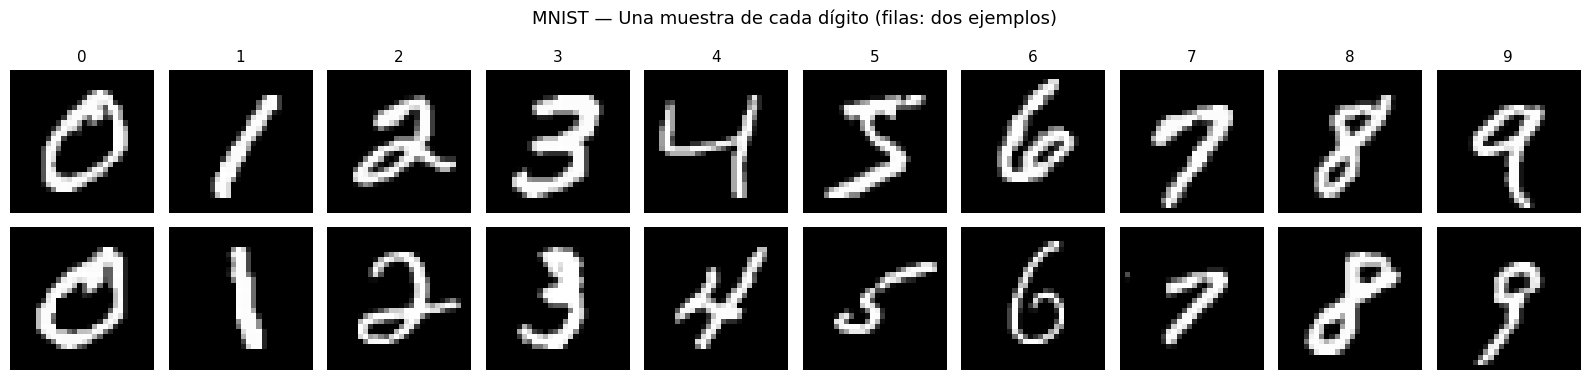

In [7]:
# Visualizar muestras de cada clase
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('MNIST — Una muestra de cada dígito (filas: dos ejemplos)', fontsize=13)

for digit in range(10):
    # Obtener índices de ese dígito
    idx = np.where(y_train == digit)[0]
    
    # Fila 1: primer ejemplo
    axes[0, digit].imshow(X_train[idx[0], :, :, 0], cmap='gray')
    axes[0, digit].axis('off')
    axes[0, digit].set_title(f'{digit}', fontsize=11)
    
    # Fila 2: segundo ejemplo
    axes[1, digit].imshow(X_train[idx[1], :, :, 0], cmap='gray')
    axes[1, digit].axis('off')

plt.tight_layout()
plt.savefig('../figures/02_mnist_muestras.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
"""
## 4. Separar un conjunto de validación

MNIST ya viene dividido en train (60,000) y test (10,000).
Sin embargo necesitamos un conjunto de "validación" separado del test
para monitorear el entrenamiento.

Vamos a tomar los últimos 10,000 ejemplos del train como validación:

Train original: 60,000
↓
Train final:   50,000  (primeros 50,000)
Validación:    10,000  (últimos 10,000)
Test:          10,000  (separado por Keras — no lo tocamos)

Nunca usamos el test set para tomar decisiones durante el entrenamiento.
Su único propósito es la evaluación final.
"""

'\n## 4. Separar un conjunto de validación\n\nMNIST ya viene dividido en train (60,000) y test (10,000).\nSin embargo necesitamos un conjunto de "validación" separado del test\npara monitorear el entrenamiento.\n\nVamos a tomar los últimos 10,000 ejemplos del train como validación:\n\nTrain original: 60,000\n↓\nTrain final:   50,000  (primeros 50,000)\nValidación:    10,000  (últimos 10,000)\nTest:          10,000  (separado por Keras — no lo tocamos)\n\nNunca usamos el test set para tomar decisiones durante el entrenamiento.\nSu único propósito es la evaluación final.\n'

In [9]:
# Separar validación de train
X_val   = X_train[50000:]
y_val   = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

# Verificar balance de clases en train
unique, counts = np.unique(y_train, return_counts=True)
print(f"\nBalance de clases en train:")
for digit, count in zip(unique, counts):
    print(f"  Dígito {digit}: {count} muestras")

Train: 50000 muestras
Val:   10000 muestras
Test:  10000 muestras

Balance de clases en train:
  Dígito 0: 4932 muestras
  Dígito 1: 5678 muestras
  Dígito 2: 4968 muestras
  Dígito 3: 5101 muestras
  Dígito 4: 4859 muestras
  Dígito 5: 4506 muestras
  Dígito 6: 4951 muestras
  Dígito 7: 5175 muestras
  Dígito 8: 4842 muestras
  Dígito 9: 4988 muestras


In [10]:
"""
## 5. Arquitectura de la CNN para MNIST

Usamos una arquitectura similar al notebook 01 con dos ajustes clave:
- Input de 28×28×1 en vez de 32×32×1
- Salida de "10 neuronas con Softmax" en vez de 1 con Sigmoid
Input (28×28×1)
↓
Conv2D(32, 3×3) → ReLU
↓
MaxPooling2D(2×2)   → output: 14×14×32
↓
Conv2D(64, 3×3) → ReLU
↓
MaxPooling2D(2×2)   → output: 7×7×64
↓
Flatten             → output: 3136
↓
Dense(128) → ReLU
↓
Dense(10) → Softmax → output: 10 probabilidades

Aumentamos los filtros (32 y 64) y las neuronas densas (128) respecto
al notebook 01 porque MNIST es más complejo que círculos vs cuadrados.
"""

'\n## 5. Arquitectura de la CNN para MNIST\n\nUsamos una arquitectura similar al notebook 01 con dos ajustes clave:\n- Input de 28×28×1 en vez de 32×32×1\n- Salida de "10 neuronas con Softmax" en vez de 1 con Sigmoid\nInput (28×28×1)\n↓\nConv2D(32, 3×3) → ReLU\n↓\nMaxPooling2D(2×2)   → output: 14×14×32\n↓\nConv2D(64, 3×3) → ReLU\n↓\nMaxPooling2D(2×2)   → output: 7×7×64\n↓\nFlatten             → output: 3136\n↓\nDense(128) → ReLU\n↓\nDense(10) → Softmax → output: 10 probabilidades\n\nAumentamos los filtros (32 y 64) y las neuronas densas (128) respecto\nal notebook 01 porque MNIST es más complejo que círculos vs cuadrados.\n'

In [11]:
def build_cnn_mnist(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        # --- Bloque 1 ---
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # --- Bloque 2 ---
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # --- Clasificador ---
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')  # 10 clases
    ])
    return model

model = build_cnn_mnist()
model.summary()

C:\Users\Peter\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
"""
## 6. Compilar y entrenar

Usamos "sparse_categorical_crossentropy" como función de loss porque:

- Tenemos "más de 2 clases" → necesitamos crossentropy categórica
- Las etiquetas son "enteros" (0, 1, 2...9) → usamos la versión "sparse"
  que acepta enteros directamente sin necesidad de convertirlos a one-hot

Si las etiquetas fueran one-hot vectors como [0,0,1,0,0,0,0,0,0,0] usaríamos "categorical_crossentropy". Con "sparse" nos ahorramos esa conversión.

"""

'\n## 6. Compilar y entrenar\n\nUsamos "sparse_categorical_crossentropy" como función de loss porque:\n\n- Tenemos "más de 2 clases" → necesitamos crossentropy categórica\n- Las etiquetas son "enteros" (0, 1, 2...9) → usamos la versión "sparse"\n  que acepta enteros directamente sin necesidad de convertirlos a one-hot\n\nSi las etiquetas fueran one-hot vectors como [0,0,1,0,0,0,0,0,0,0] usaríamos "categorical_crossentropy". Con "sparse" nos ahorramos esa conversión.\n\n'

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Multiclase con etiquetas enteras
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9484 - loss: 0.1689 - val_accuracy: 0.9836 - val_loss: 0.0576
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9846 - loss: 0.0504 - val_accuracy: 0.9858 - val_loss: 0.0469
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9901 - loss: 0.0328 - val_accuracy: 0.9862 - val_loss: 0.0479
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9928 - loss: 0.0224 - val_accuracy: 0.9880 - val_loss: 0.0473
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9945 - loss: 0.0163 - val_accuracy: 0.9864 - val_loss: 0.0555
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9952 - loss: 0.0134 - val_accuracy: 0.9878 - val_loss: 0.0502
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9957 - loss: 0.0112 - val_accuracy: 0.9893 - val_loss: 0.0479
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9966 - loss: 0.0094 - 

In [14]:
"""
## 7. Visualizar el entrenamiento

A diferencia del notebook 01 donde ambas curvas convergieron perfectamente,
acá vamos a ver algo más interesante:

- La "train loss" sigue bajando epoch a epoch
- La "val loss" empieza a subir levemente después de la epoch 7

Esto es una señal temprana de "overfitting" — el modelo empieza a
memorizar el train set en vez de seguir generalizando.
En el notebook 07 vamos a ver cómo detectarlo y corregirlo.
"""

'\n## 7. Visualizar el entrenamiento\n\nA diferencia del notebook 01 donde ambas curvas convergieron perfectamente,\nacá vamos a ver algo más interesante:\n\n- La "train loss" sigue bajando epoch a epoch\n- La "val loss" empieza a subir levemente después de la epoch 7\n\nEsto es una señal temprana de "overfitting" — el modelo empieza a\nmemorizar el train set en vez de seguir generalizando.\nEn el notebook 07 vamos a ver cómo detectarlo y corregirlo.\n'

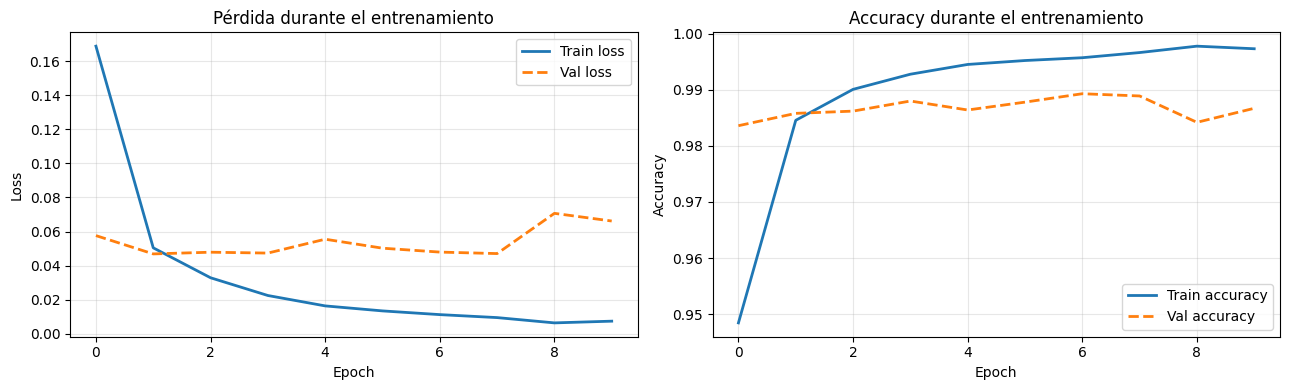

In [15]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train loss',  linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',    linewidth=2, linestyle='--')
    axes[0].set_title('Pérdida durante el entrenamiento')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train accuracy',  linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy',    linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy durante el entrenamiento')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('../figures/02_training_history.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history)

In [16]:
"""
## 8. Evaluación detallada — Matriz de confusión

El accuracy global es útil pero no nos dice **dónde** se equivoca el modelo.
La matriz de confusión nos muestra exactamente qué clases confunde con cuáles.
Predicho
            0   1   2   3   4   5   6   7   8   9
        0 [980   0   0   0   0   0   0   0   0   0]
        1 [  0 1133   0   0   0   0   0   0   0   0]

Real   2 [  0   0 1030   0   0   0   0   2   0   0]
       3 [  0   0   0 1005   0   3   0   0   2   0]
- La "diagonal principal" son los aciertos
- Los valores "fuera de la diagonal" son los errores
- Si el modelo confunde mucho el 4 con el 9, veremos un valor alto en la fila 4, columna 9
"""

'\n## 8. Evaluación detallada — Matriz de confusión\n\nEl accuracy global es útil pero no nos dice **dónde** se equivoca el modelo.\nLa matriz de confusión nos muestra exactamente qué clases confunde con cuáles.\nPredicho\n            0   1   2   3   4   5   6   7   8   9\n        0 [980   0   0   0   0   0   0   0   0   0]\n        1 [  0 1133   0   0   0   0   0   0   0   0]\n\nReal   2 [  0   0 1030   0   0   0   0   2   0   0]\n       3 [  0   0   0 1005   0   3   0   0   2   0]\n- La "diagonal principal" son los aciertos\n- Los valores "fuera de la diagonal" son los errores\n- Si el modelo confunde mucho el 4 con el 9, veremos un valor alto en la fila 4, columna 9\n'

Test Loss:     0.0443
Test Accuracy: 0.9895 (98.9%)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.97      0.99      0.98      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



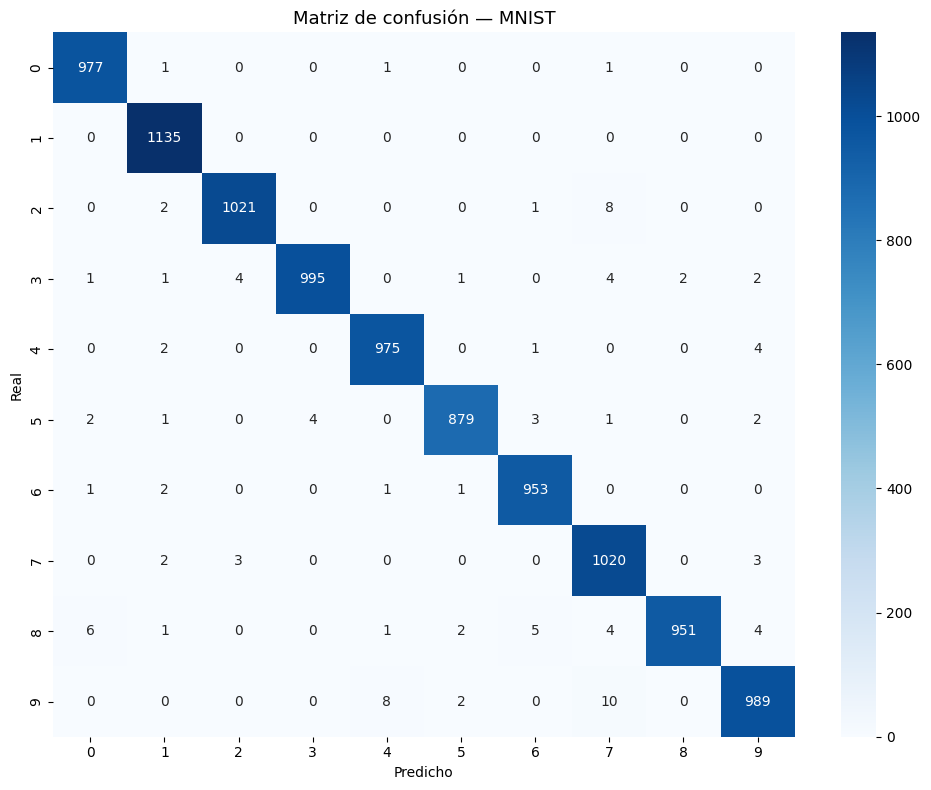

In [17]:
# Evaluación global
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print()

# Predicciones
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Reporte por clase
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de confusión — MNIST', fontsize=13)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('../figures/02_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
"""
## 9. Análisis de errores

El accuracy global es 99%, pero ¿qué pasa con ese 1% de errores?
Visualizar las imágenes que el modelo clasificó mal nos da intuición
sobre los límites del modelo y sobre la dificultad inherente del dataset.

Muchos de estos errores son imágenes que un humano también dudaría en clasificar — escrituras ambiguas o poco claras.
"""

'\n## 9. Análisis de errores\n\nEl accuracy global es 99%, pero ¿qué pasa con ese 1% de errores?\nVisualizar las imágenes que el modelo clasificó mal nos da intuición\nsobre los límites del modelo y sobre la dificultad inherente del dataset.\n\nMuchos de estos errores son imágenes que un humano también dudaría en clasificar — escrituras ambiguas o poco claras.\n'

Total de errores: 105 sobre 10000 imágenes


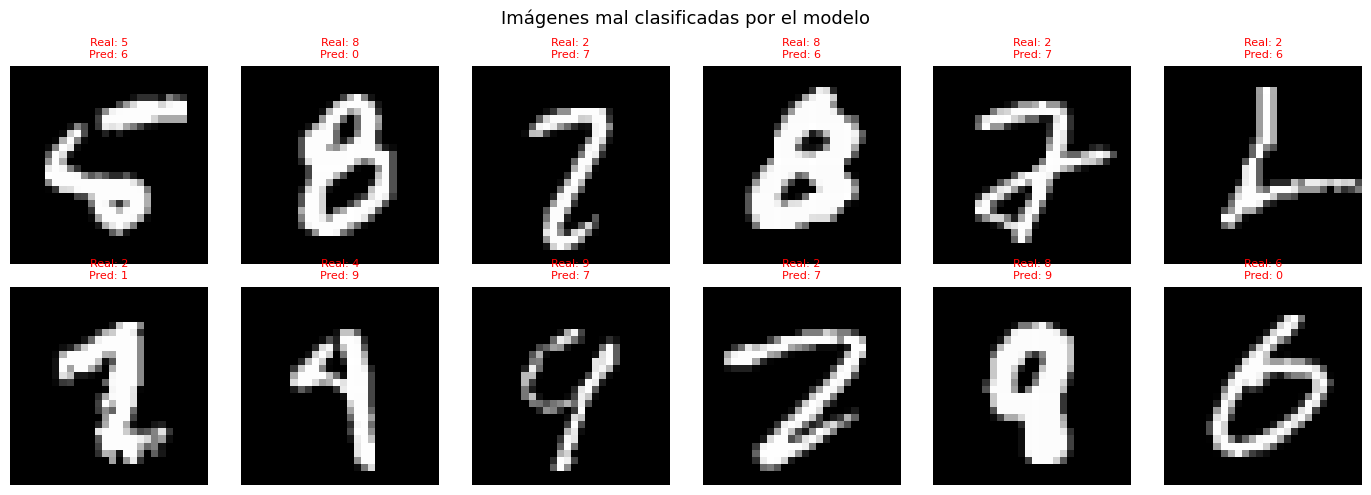

In [19]:
# Encontrar índices donde el modelo se equivocó
error_idx = np.where(y_pred != y_test)[0]
print(f"Total de errores: {len(error_idx)} sobre {len(y_test)} imágenes")

# Visualizar los primeros 12 errores
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Imágenes mal clasificadas por el modelo', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    idx = error_idx[i]
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'Real: {y_test[idx]}\nPred: {y_pred[idx]}',
                 fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/02_errores.png', dpi=120, bbox_inches='tight')
plt.show()

In [20]:
"""
## 10. Guardar el modelo

Guardamos el modelo entrenado en la carpeta "models/" para poder
reutilizarlo en notebooks posteriores.

En el "notebook 03" vamos a cargar este mismo modelo para visualizar
los feature maps — es decir, vamos a ver exactamente qué detecta
cada filtro convolucional en cada capa.
"""

'\n## 10. Guardar el modelo\n\nGuardamos el modelo entrenado en la carpeta "models/" para poder\nreutilizarlo en notebooks posteriores.\n\nEn el "notebook 03" vamos a cargar este mismo modelo para visualizar\nlos feature maps — es decir, vamos a ver exactamente qué detecta\ncada filtro convolucional en cada capa.\n'

In [21]:
model.save('../models/02_cnn_mnist.keras')
print("Modelo guardado en ../models/02_cnn_mnist.keras")

Modelo guardado en ../models/02_cnn_mnist.keras
